In [2]:

from pathlib import Path
import gc
import os
import time
import threading
import warnings

import pandas as pd
import polars as pl

#监控内存占用用的
import psutil
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_rows(20)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "train.parquet"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
RAW_SUBSET_DIR = ARTIFACT_DIR / "raw_subsets"
CLEAN_SUBSET_DIR = ARTIFACT_DIR / "clean_subsets"

for folder in [ARTIFACT_DIR, RAW_SUBSET_DIR, CLEAN_SUBSET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"当前工作目录: {PROJECT_DIR}")
print(f"数据文件存在: {DATA_PATH.exists()} -> {DATA_PATH}")
print(f"pandas 版本: {pd.__version__}")
print(f"polars 版本: {pl.__version__}")
print(f"psutil 版本: {psutil.__version__}")


当前工作目录: /Users/fangflak/Desktop/CI_proj
数据文件存在: True -> /Users/fangflak/Desktop/CI_proj/train.parquet
pandas 版本: 2.3.3
polars 版本: 1.37.1
psutil 版本: 7.0.0


# Cell 12: Baseline EDA
This section performs baseline exploratory data analysis using the cleaned dataset generated in previous steps.

In [3]:
# Load cleaned dataset (100% for EDA)
df = pl.read_parquet("artifacts/clean_subsets/train_clean_100pct.parquet")

df.head()


event_time,event_type,product_id,brand,price,user_id,user_session,target,cat_0,cat_1,cat_2,cat_3,timestamp,ts_hour,ts_minute,ts_weekday,ts_day,ts_month,ts_year,event_timestamp,event_date,event_hour,event_weekday,event_day,event_month,event_year
str,str,str,str,f64,str,str,i8,str,str,str,str,datetime[μs],i16,i16,i16,i16,i16,i16,datetime[μs],datetime[μs],i16,i16,i16,i16,i16
"""2019-11-01 00:00:14 UTC""","""cart""","""1005014""","""samsung""",503.09,"""533326659""","""6b928be2-2bce-4640-8296-0efdf2…",0,"""electronics""","""smartphone""",null,null,2019-11-01 00:00:14,0,0,4,1,11,2019,2019-11-01 00:00:14,2019-11-01 00:00:00,0,4,1,11,2019
"""2019-11-01 00:03:39 UTC""","""cart""","""1005115""","""apple""",949.47,"""565865924""","""fd4bd6d4-bd14-4fdc-9aff-bd41a5…",0,"""electronics""","""smartphone""",null,null,2019-11-01 00:03:39,0,3,4,1,11,2019,2019-11-01 00:03:39,2019-11-01 00:00:00,0,4,1,11,2019
"""2019-11-01 00:05:54 UTC""","""cart""","""1002542""","""apple""",486.8,"""549256216""","""dcbdc6e4-cd49-4ee8-95c5-e85f3c…",0,"""electronics""","""smartphone""",null,null,2019-11-01 00:05:54,0,5,4,1,11,2019,2019-11-01 00:05:54,2019-11-01 00:00:00,0,4,1,11,2019
"""2019-11-01 00:07:22 UTC""","""cart""","""1002542""","""apple""",486.8,"""549256216""","""dcbdc6e4-cd49-4ee8-95c5-e85f3c…",0,"""electronics""","""smartphone""",null,null,2019-11-01 00:07:22,0,7,4,1,11,2019,2019-11-01 00:07:22,2019-11-01 00:00:00,0,4,1,11,2019
"""2019-11-01 00:10:45 UTC""","""cart""","""4804056""","""apple""",160.57,"""522355747""","""0a1f37d1-71b7-4645-a8a7-ab91bc…",0,"""electronics""","""audio""","""headphone""",null,2019-11-01 00:10:45,0,10,4,1,11,2019,2019-11-01 00:10:45,2019-11-01 00:00:00,0,4,1,11,2019


# Cell 13: Event Type Distribution

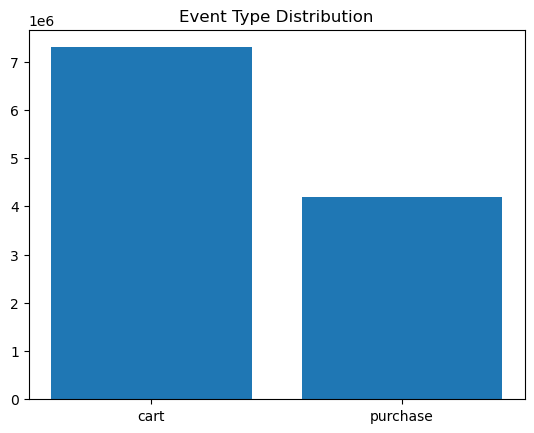

In [4]:
event_dist = (
    df
    .group_by("event_type")
    .count()
    .sort("count", descending=True)
)

event_dist_pd = event_dist.to_pandas()

import matplotlib.pyplot as plt

plt.bar(event_dist_pd["event_type"], event_dist_pd["count"])
plt.title("Event Type Distribution")
plt.show()

# Cell 14: Session Length Distribution

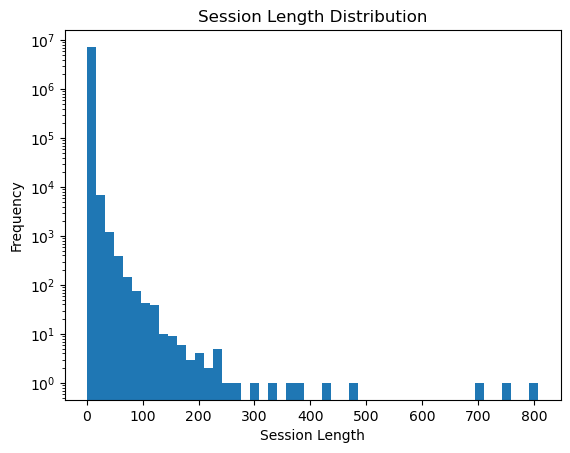

In [5]:
session_length = (
    df
    .group_by("user_session")
    .count()
    .rename({"count": "session_length"})
)

session_length_pd = session_length.to_pandas()

plt.hist(session_length_pd["session_length"], bins=50)
plt.title("Session Length Distribution")
plt.xlabel("Session Length")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

# Cell 14: Daily trend analysis

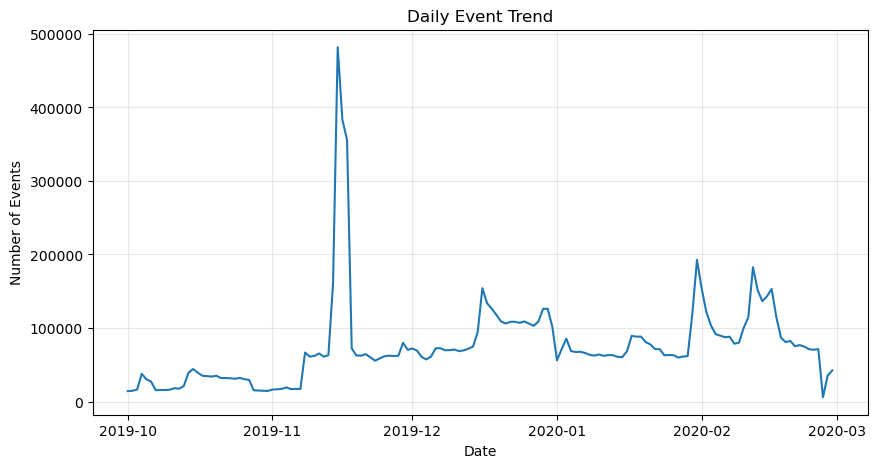

In [6]:
daily_trend = (
    df
    .group_by("event_date")
    .count()
    .sort("event_date")
)

daily_trend_pd = daily_trend.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(daily_trend_pd["event_date"], daily_trend_pd["count"])
plt.title("Daily Event Trend")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.grid(alpha=0.3)
plt.show()

# Cell 15: User Activity Distribution

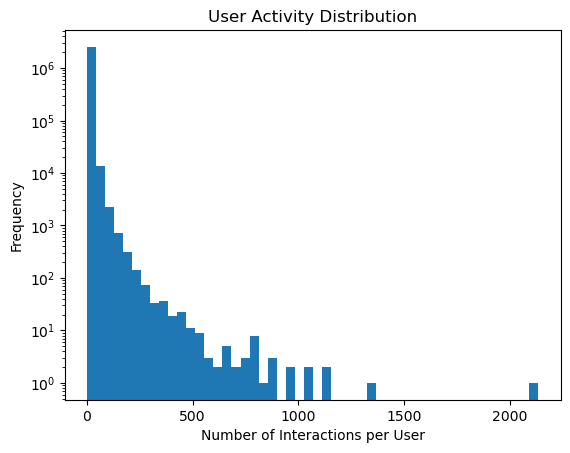

In [7]:
user_activity = (
    df
    .group_by("user_id")
    .count()
    .rename({"count": "activity"})
)

user_activity_pd = user_activity.to_pandas()

plt.hist(user_activity_pd["activity"], bins=50)
plt.title("User Activity Distribution")
plt.xlabel("Number of Interactions per User")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

# Cell 16: Top 10 Products

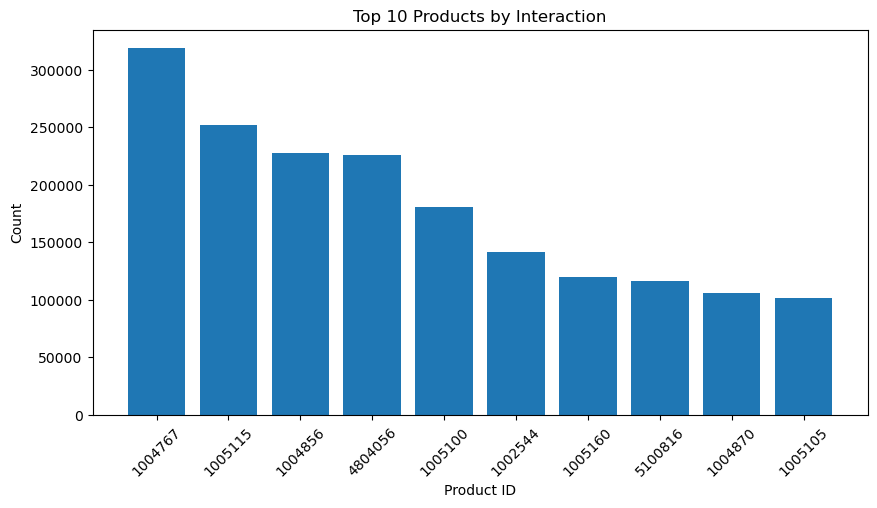

In [8]:
top_products = (
    df
    .group_by("product_id")
    .count()
    .sort("count", descending=True)
    .head(10)
)

top_products_pd = top_products.to_pandas()

plt.figure(figsize=(10, 5))
plt.bar(top_products_pd["product_id"].astype(str), top_products_pd["count"])
plt.title("Top 10 Products by Interaction")
plt.xlabel("Product ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Cell 17: Category Distribution

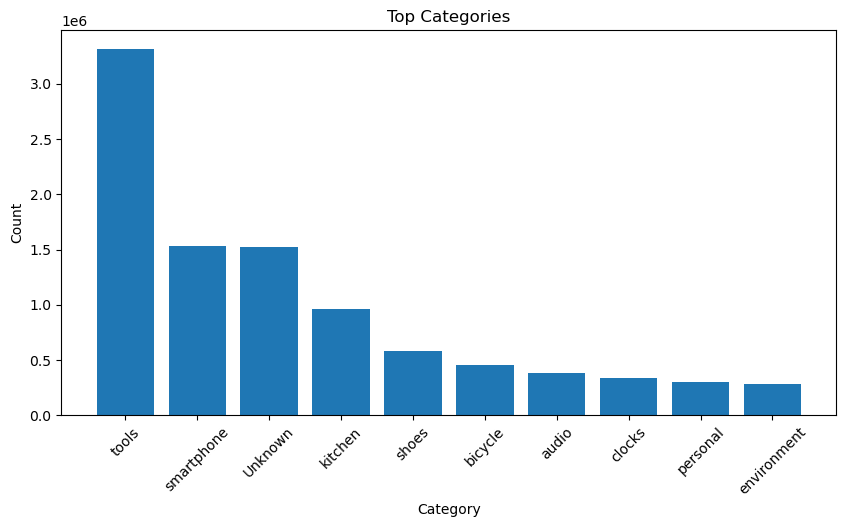

In [9]:
# Category Distribution
cat_dist = (
    df
    .with_columns(
        pl.col("cat_1").fill_null("Unknown")
    )
    .group_by("cat_1")
    .count()
    .sort("count", descending=True)
    .head(10)
)

cat_dist_pd = cat_dist.to_pandas()

plt.figure(figsize=(10, 5))
plt.bar(cat_dist_pd["cat_1"].astype(str), cat_dist_pd["count"])
plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Cell 18: Hourly Pattern

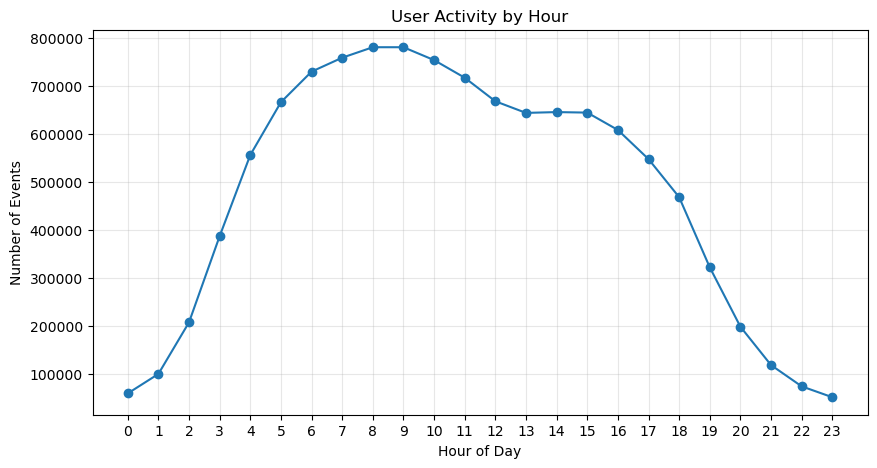

In [10]:
# Hourly Activity
hourly = (
    df
    .group_by("ts_hour")
    .count()
    .sort("ts_hour")
)

hourly_pd = hourly.to_pandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["ts_hour"], hourly_pd["count"], marker='o')

plt.title("User Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")

plt.xticks(range(0, 24, 1))

plt.grid(alpha=0.3)
plt.show()